# LS-LRSI: Exploratory Data Analysis
## Aranayake, Kegalle District, Sri Lanka

**Student Name:** Aabidha Rifky
**ICBT SIS ID:** CL/MCSDS/CMU/10/04
**Cardiff Met ID:** st20357374
**Module:** DAS7003 Geospatial Analysis
**Assessment:** PRAC1

---

## Purpose

`02_preprocessing.ipynb` produced nine aligned layers, all sharing the same 221 x 221 grid: elevation, slope, aspect, curvature, NDVI, distance to road, distance to stream, rainfall, and soil clay content. This notebook combines them into a single table, checks the data for issues, and examines the distribution and relationships between indicators before they are combined into the risk index in `04_index_construction.ipynb`.

## 1. Load Processed Layers into a Single Table

Each processed layer is currently a separate 221 x 221 grid stored in its own file. This section loads all nine, and reshapes each one from a 2D grid into a single column, so that every one of the 48,841 grid cells becomes one row in a table, with one column per indicator. This structure is what the summary statistics, histograms, and correlation analysis below are built on.

In [12]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

PROCESSED_DIR = "../data/processed"

layer_files = {
    "elevation_m": "dem_30m.tif",
    "slope_deg": "slope_30m.tif",
    "aspect_deg": "aspect_30m.tif",
    "curvature": "curvature_30m.tif",
    "ndvi": "ndvi_30m.tif",
    "dist_road_m": "dist_road_30m.tif",
    "dist_stream_m": "dist_stream_30m.tif",
    "rainfall_mm": "rainfall_30m.tif",
    "soil_clay_pct": "soil_clay_30m.tif",
}

layers = {}
for name, filename in layer_files.items():
    with rasterio.open(f"{PROCESSED_DIR}/{filename}") as src:
        layers[name] = src.read(1)

grid_shape = layers["elevation_m"].shape
print(f"Grid shape confirmed: {grid_shape}")

data = pd.DataFrame({name: arr.flatten() for name, arr in layers.items()})
print(f"Table shape: {data.shape[0]} grid cells, {data.shape[1]} indicators")
data.head()

Grid shape confirmed: (221, 221)
Table shape: 48841 grid cells, 9 indicators


,elevation_m,slope_deg,aspect_deg,curvature,ndvi,dist_road_m,dist_stream_m,rainfall_mm,soil_clay_pct
0,216.000000,9.244759,246.716431,0.153813,0.532479,108.166542,3270.0,296.290558,35.804348
1,220.485321,11.834031,269.451294,0.084702,0.580208,84.852814,3240.0,296.266327,35.804348
2,228.571274,14.237419,277.363617,0.012570,0.514886,60.000000,3210.0,296.242096,35.804348
3,235.583801,13.102160,292.709991,-0.067308,0.457835,30.000000,3180.0,296.217896,35.804348
4,241.453415,12.224784,319.652771,-0.137912,0.450434,0.000000,3150.0,296.193695,35.804348


Grid shape should read 221 x 221, matching every processed layer confirmed in `02_preprocessing.ipynb`. The table shape should show 48,841 rows and 9 columns, one per indicator. If any of the nine files failed to load or came from a different grid, this cell would raise an error rather than silently combining mismatched data, since pandas requires all input arrays to have the same shape.

In [13]:
missing_counts = data.isna().sum()
print("Missing values per indicator:")
print(missing_counts)

Missing values per indicator:
elevation_m      0
slope_deg        0
aspect_deg       0
curvature        0
ndvi             0
dist_road_m      0
dist_stream_m    0
rainfall_mm      0
soil_clay_pct    0
dtype: int64


Zero missing values are expected across all nine columns. This confirms `02_preprocessing.ipynb` produced complete coverage across the full grid, with no gaps from reprojection edge effects, nodata regions, or the sample-and-interpolate soil layer.

## 2. Summary Statistics

This table shows the minimum, maximum, mean, and spread of each indicator across the full study area, giving a first check of whether the data is physically sensible before it goes into the risk index.

In [16]:
data.describe().round(2)

,elevation_m,slope_deg,aspect_deg,curvature,ndvi,dist_road_m,dist_stream_m,rainfall_mm,soil_clay_pct
count,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00,48841.00
mean,226.69,12.02,178.41,-0.00,0.46,148.54,1660.66,295.42,35.77
std,46.26,6.42,103.72,0.13,0.07,124.88,971.83,21.63,1.15
min,55.89,0.05,0.00,-1.14,0.08,0.00,0.00,247.01,33.02
25%,196.34,7.09,84.06,-0.09,0.43,42.43,853.29,277.00,35.08
50%,224.05,11.30,187.34,-0.00,0.47,120.00,1626.93,296.83,35.77
75%,256.96,16.11,263.82,0.09,0.51,216.33,2412.34,315.35,36.52
max,371.77,57.56,359.97,0.68,0.66,697.78,4092.00,327.76,38.46


Elevation, slope, and rainfall figures should be consistent with the values already confirmed in `01_data_acquisition.ipynb` and `02_preprocessing.ipynb`: elevation roughly 56-372 m, slope averaging around 12 degrees with a maximum near 58 degrees, and rainfall in the 247-328 mm range. NDVI should stay within its theoretical -1 to 1 bounds. Distance to road and distance to stream should not exceed the physical size of the study area, roughly 6.6 km across the diagonal. Soil clay content should sit within roughly 33-38.5%, matching the range confirmed directly in `02_preprocessing.ipynb`, since that layer was built by interpolating the same sampled points checked there.

## 3. Distribution of Each Indicator

Histograms show how spread out each indicator is across the study area. An indicator with most values clustered narrowly in one place is less useful for telling risky and safe ground apart than one with a wide spread, since a wide spread means the indicator actually varies meaningfully from location to location within Aranayake.                                                                                                                           Soil clay content is expected to show a fairly narrow, roughly bell-shaped distribution, since it was produced by smooth interpolation across a small number of sample points rather than measured independently at every cell, so sharp jumps or multiple peaks would not be expected here.                   

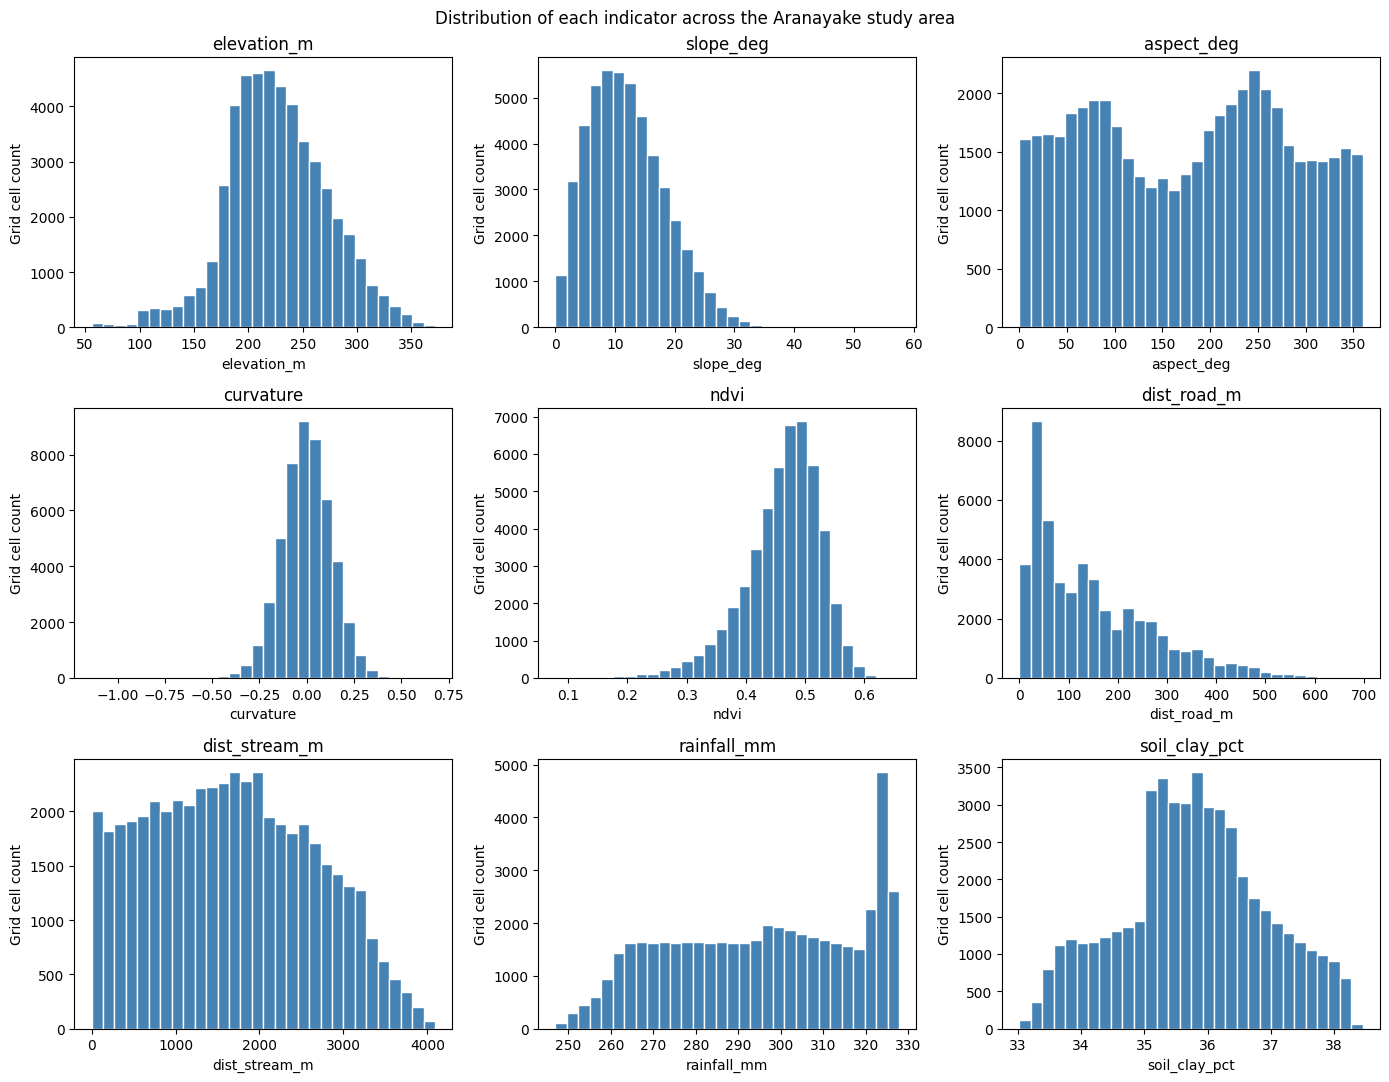

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
columns_to_plot = list(layer_files.keys())

for ax, col in zip(axes.flatten(), columns_to_plot):
    ax.hist(data[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Grid cell count")

plt.suptitle("Distribution of each indicator across the Aranayake study area")
plt.tight_layout()
plt.savefig("../outputs/figures/fig1_histograms.png", dpi=150)
plt.show()

Slope and rainfall are expected to show a fairly tight, unimodal distribution, most of the study area shares a broadly similar value, with a tail toward higher values in the steepest or wettest sections. Distance to road and distance to stream are expected to show a wider, more spread-out distribution, since these values grow steadily with distance from the nearest linear feature rather than clustering around one typical value. Aspect shows two clear peaks rather than an even spread, roughly 0-90 degrees and 200-300 degrees, with fewer cells facing the directions in between. This is consistent with Aranayake's valley and ridge terrain, where slopes tend to face one of two dominant directions rather than being randomly oriented, and reflects real landscape structure rather than a data issue.

## 4. Correlation Between Indicators

Before combining indicators into a single index, it's worth checking whether any of them are essentially measuring the same thing. If two indicators are very strongly correlated, including both in the index would count that piece of information twice, giving it more influence than intended. This check covers the six indicators actually used in the index calculation in `04_index_construction.ipynb` (slope, NDVI, distance to road, distance to stream, rainfall, and soil clay content), plus curvature, checked here for exploratory purposes even though it is not included in the final index. Elevation and aspect are excluded from this check as neither is used directly in the final score.

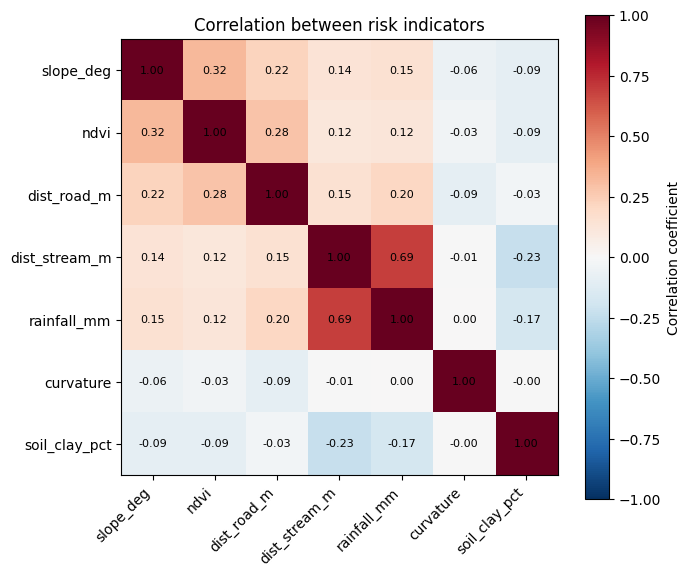

,slope_deg,ndvi,dist_road_m,dist_stream_m,rainfall_mm,curvature,soil_clay_pct
slope_deg,1.00,0.32,0.22,0.14,0.15,-0.06,-0.09
ndvi,0.32,1.00,0.28,0.12,0.12,-0.03,-0.09
dist_road_m,0.22,0.28,1.00,0.15,0.20,-0.09,-0.03
dist_stream_m,0.14,0.12,0.15,1.00,0.69,-0.01,-0.23
rainfall_mm,0.15,0.12,0.20,0.69,1.00,0.00,-0.17
curvature,-0.06,-0.03,-0.09,-0.01,0.00,1.00,-0.00
soil_clay_pct,-0.09,-0.09,-0.03,-0.23,-0.17,-0.00,1.00


In [15]:
corr_columns = ["slope_deg", "ndvi", "dist_road_m", "dist_stream_m", "rainfall_mm", "curvature", "soil_clay_pct"]
correlation = data[corr_columns].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)))
ax.set_yticks(range(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha="right")
ax.set_yticklabels(corr_columns)

for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation between risk indicators")
plt.colorbar(im, ax=ax, label="Correlation coefficient")
plt.tight_layout()
plt.savefig("../outputs/figures/fig2_correlation.png", dpi=150)
plt.show()

correlation.round(2)

Each cell shows the correlation coefficient between two indicators, ranging from -1 (perfectly opposite) through 0 (unrelated) to 1 (perfectly matched). The diagonal is always 1.00, since every indicator is perfectly correlated with itself.

The strongest relationship in this matrix is between distance to stream and rainfall (0.69), noticeably stronger than any other pair. This makes physical sense for this specific location: the study area's rainfall layer varies with elevation (an orographic effect, higher ground receives more rain), and elevation and distance from the stream are themselves closely linked in this valley terrain, ground far from the stream tends to sit higher up the slope. This is a real, explainable spatial pattern rather than a data error, though it is worth noting as a factor when interpreting the index later: these two indicators are not fully independent of each other.

Slope and NDVI show a weak-to-moderate positive correlation (0.32), consistent with steeper slopes in this recentred area retaining relatively more vegetation cover than the flatter, more accessible ground near roads and the valley floor. Slope also correlates weakly with distance to road (0.22) and distance to stream (0.14), both positive, reflecting the same pattern.

Soil clay content shows weak negative correlations with distance to stream (-0.23) and rainfall (-0.17), consistent with clay-rich soil tending to accumulate in wetter, lower-lying ground. Curvature shows negligible correlation with every other indicator (all below 0.10 in magnitude).

No pair of indicators exceeds the 0.5-0.6 range generally considered acceptable for inclusion in an additive index; the 0.69 correlation between distance to stream and rainfall is the only one worth flagging explicitly, and while it does not reach the 0.8-0.9 threshold that would signal genuine redundancy, it is close enough to be worth acknowledging as a limitation, that these two specific indicators may be partially capturing overlapping information, in the report's discussion of the index design (Step 5 or Step 6).